### Import Libraries

In [2]:
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
import pandas as pd
from sklearn import preprocessing as prep
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split

### Load and Inspect the Dataset

In [4]:
df= pd.read_csv('IMDB-Dataset.csv')
lb= LabelEncoder()
df['sentiment']= lb.fit_transform(df['sentiment'])
df.head()
#print(len(df))

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


### Text Cleaning and Preprocessing

In [6]:
comments= df["review"].astype(str).tolist()
import re
tokenized_comments= []
for c in comments:
    token= re.sub(r'[^A-Za-z0-9]+', ' ', c)
    token= token.lower().split()
    tokenized_comments.append(token)

print(len(tokenized_comments))
#print(tokenized_comments[0])

50000


### Manual Bag of Words Implementation

In [8]:
vocab_size= 5000
word_freq= {}
# first find most frequent words in vocabulary
for tokens in tokenized_comments:
    for token in tokens:
        if token in word_freq and token.isalpha():
            word_freq[token] +=1
        else:
            word_freq[token]= 1
# sort words by frequency
sorted_words= sorted(word_freq.items(), key=lambda x:x[1], reverse=True)

### create word to index mapping

In [10]:
most_frequent_words= [word for word, freq in sorted_words[:vocab_size]]
vocab= most_frequent_words
vocab2idx= {w: i+1 for i, w in enumerate(vocab)}
vocab2idx['<UKN>']= 0 
vocab_size += 1
#print(vocab)
#print(vocab2idx)

### define bow vectorizer

In [12]:
def vectorize_bow(tokens, vocab2idx, vocab_size):
    features= np.zeros((len(tokens), vocab_size), dtype= np.float64)
    for i, token in enumerate(tokens):
        for j, word in enumerate(token):
            if word in vocab2idx:
                features[i, vocab2idx[word]]+= 1
            else:
                features[i, vocab2idx['<UKN>']]+= 1
    return features

### Train-Test Split

In [14]:
xtrain, xtest, ytrain, ytest= train_test_split(tokenized_comments, df["sentiment"].values,
                                               test_size=0.2 ,
                                               random_state=42
                                              )
print(len(xtrain), len(xtest))
print(np.unique(ytrain, return_counts=True))


40000 10000
(array([0, 1]), array([20039, 19961], dtype=int64))


### define customdataset

In [16]:
class CustomDataset(Dataset):
    def __init__(self, comments, labels, vocab_size, vocab2idx):
        self.tokenized_comments= comments
        self.y= labels
        self.vocab_size= vocab_size
        self.vocab2idx= vocab2idx

    def __len__(self):
        return len(self.tokenized_comments)

    def __getitem__(self, idx):
        tokens= self.tokenized_comments[idx]
        x= vectorize_bow([tokens], self.vocab2idx,self.vocab_size)
        y= self.y[idx]
        # convert to PyTorch tensors
        x= torch.tensor(x, dtype= torch.float32).squeeze(0)
        y= torch.tensor(y, dtype= torch.long)
        return x, y
        
        

### create Customdataset for train and test data

In [18]:
ds_train= CustomDataset(xtrain, ytrain, vocab_size, vocab2idx)
ds_test= CustomDataset(xtest, ytest, vocab_size, vocab2idx)


In [19]:
f, y= ds_train[0]
print(f)
print(y)


tensor([43., 24., 11.,  ...,  0.,  0.,  0.])
tensor(0)


### create DataLoader for batching

In [21]:
train_loader= DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader= DataLoader(ds_test, batch_size=32, shuffle=False)

### create MLP model

In [23]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        self.fc1= nn.Linear(input_size, hidden_size)
        self.relu= nn.ReLU()
        self.fc2= nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out= self.fc1(x)
        out= self.relu(out)
        out= self.fc2(out)
        return out

In [24]:
model= MLP(input_size= vocab_size,
            hidden_size=128,
            num_classes=2)
# optimizer and loss function
criterion= nn.CrossEntropyLoss()
optemizer= optim.Adam(model.parameters(), lr= 0.001)

### Model Train

In [26]:
num_epochs= 10
train_losses= []
for epoch in range(num_epochs):
    model.train()
    epoch_loss= 0.0
    for x_batch, y_batch in train_loader:
        optemizer.zero_grad()
        outputs= model(x_batch)
        loss= criterion(outputs, y_batch)
        loss.backward()
        optemizer.step()
        epoch_loss += loss.item()*x_batch.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    print(f"Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f} ")

Epoch[1/10], Loss: 0.3264 
Epoch[2/10], Loss: 0.2296 
Epoch[3/10], Loss: 0.1723 
Epoch[4/10], Loss: 0.1047 
Epoch[5/10], Loss: 0.0498 
Epoch[6/10], Loss: 0.0289 
Epoch[7/10], Loss: 0.0176 
Epoch[8/10], Loss: 0.0135 
Epoch[9/10], Loss: 0.0039 
Epoch[10/10], Loss: 0.0156 


### model evaluation

In [28]:
y_pred= []
y_true= []
model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        outputs= model(x_batch)
        _, predicted= torch.max(outputs.data, dim=1)
        y_pred.extend(predicted.numpy())
        y_true.extend(y_batch.numpy())

### evaluation metrics

Accuracy: 87.7200%
Precision: 88.1634%
Recall: 87.3586%
F1: 87.7592%


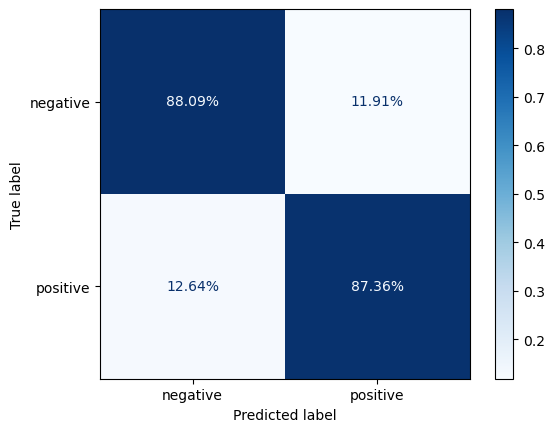

In [30]:
Accuracy= metrics.accuracy_score(y_true, y_pred)* 100
Precision= metrics.precision_score(y_true, y_pred)* 100
Recall= metrics.recall_score(y_true, y_pred)* 100
F1= metrics.f1_score(y_true, y_pred)* 100
print(f'Accuracy: {Accuracy:.4f}%')
print(f'Precision: {Precision:.4f}%')
print(f'Recall: {Recall:.4f}%')
print(f'F1: {F1:.4f}%')
cm= metrics.confusion_matrix(y_true, y_pred, normalize='true')
# normalized confusion matrix
dis= metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)

dis.plot(cmap=plt.cm.Blues, values_format='.2%')
plt.show()